# freezing on 7/26 for 1on1

In [1]:
from src.MPOptoClass import *
from src.utils.gen_utils import *

import mat73
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.decomposition import PCA


%load_ext autoreload 
%autoreload 2
%matplotlib widget

In [2]:
session_path = '/home/diya/Documents/mp_opto/data/vgat2_06062023'

session = MPOptoClass(session_path)

/home/diya/Documents/mp_opto/src/helpers/load.py:26: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  CFA['train'] = np.array((CFA['train']))
/home/diya/Documents/mp_opto/src/helpers/load.py:30: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  RFA['train'] = np.array((RFA['train']))


love


# 0. Thresholding on a log scale. 

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


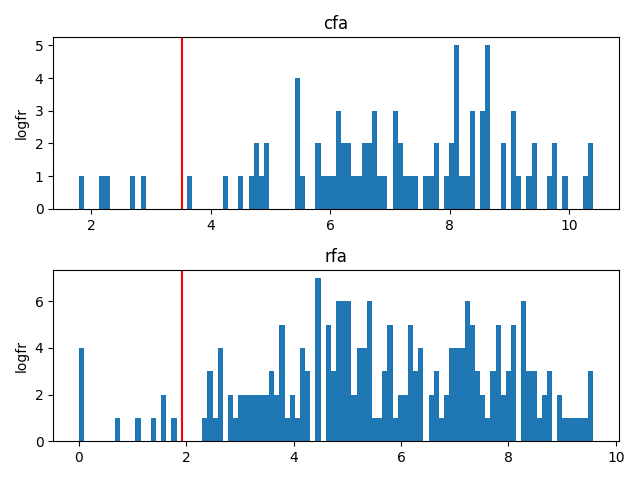

In [3]:
CFA_climbbinned, RFA_climbbinned = session.binner(bounds=session.climbing_bounds, concat=True)
CFA_logclimbsum = nanlog(np.sum(CFA_climbbinned, 0))
RFA_logclimbsum = nanlog(np.sum(RFA_climbbinned, 0))


nada, CFA_bins = np.histogram(CFA_logclimbsum, bins=100)
nada, RFA_bins = np.histogram(RFA_logclimbsum, bins=100)

CFA_thresh = CFA_bins[20]
RFA_thresh = RFA_bins[20]

fig0, ax0 = plt.subplots(2, 1)
ax0[0].hist(CFA_logclimbsum, bins=100)
ax0[0].axvline(CFA_thresh, color='r')
ax0[0].set_ylabel('logfr')
ax0[0].set_title('cfa')

ax0[1].hist(RFA_logclimbsum, bins=100)
ax0[1].axvline(RFA_thresh, color='r')
ax0[1].set_ylabel('logfr')
ax0[1].set_title('rfa')

CFA_keeps = CFA_logclimbsum > CFA_thresh
RFA_keeps = RFA_logclimbsum > RFA_thresh

fig0.tight_layout()

# 1. Binning, not smoothing!

In [4]:
pre = 20
post = 52
fs = 3

In [5]:
CFA_trialbinned, RFA_trialbinned = session.binner(bounds=session.laser_bounds[:, 2:], fs=fs)
CFA_trialbinned = CFA_trialbinned[:, CFA_keeps, :]
RFA_trialbinned = RFA_trialbinned[:, RFA_keeps, :]

CFA_ctrlbinned, RFA_ctrlbinned = session.binner(bounds=session.ctrl_bounds[:, 2:], fs=fs)
CFA_ctrlbinned = CFA_ctrlbinned[:, CFA_keeps, :]
RFA_ctrlbinned = RFA_ctrlbinned[:, RFA_keeps, :]

num_CFA = CFA_trialbinned.shape[1]
num_RFA = RFA_trialbinned.shape[1]
trial_length = CFA_trialbinned.shape[0]
num_trials = session.num_trials
num_ctrls = session.num_ctrls

print(f'num CFA neurons: {num_CFA}')
print(f'num RFA neurons: {num_RFA}')
print(f'trial length: {trial_length}')
print(f'num real trials: {num_trials}')
print(f'num ctrl trials: {num_ctrls}')

num CFA neurons: 86
num RFA neurons: 204
trial length: 40
num real trials: 46
num ctrl trials: 44


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


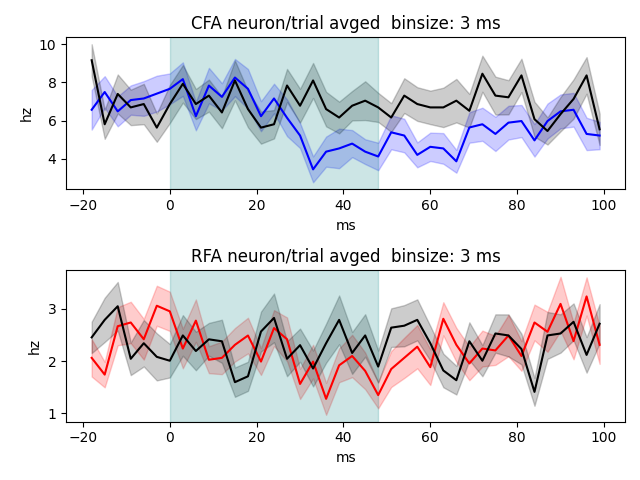

In [16]:
laser_off = session.laser_bounds[0,1] - session.laser_bounds[0,0]

CFA_timecourse_avgavg = np.average(CFA_trialbinned, axis=(1,2)) / (fs/1000)
temp = np.average(CFA_trialbinned, axis=1)
CFA_timecourse_avgsem = np.std(temp, axis=1) / np.sqrt(num_trials) / (fs/1000)

RFA_timecourse_avgavg = np.average(RFA_trialbinned, axis=(1,2)) / (fs/1000)
temp = np.average(RFA_trialbinned, axis=1)
RFA_timecourse_avgsem = np.std(temp, axis=1) / np.sqrt(num_trials) / (fs/1000)

CFA_ctrlcourse_avgavg = np.average(CFA_ctrlbinned, axis=(1,2)) / (fs/1000)
temp = np.average(CFA_ctrlbinned, axis=1)
CFA_ctrlcourse_avgsem = np.std(temp, axis=1) / np.sqrt(num_ctrls) / (fs/1000)

RFA_ctrlcourse_avgavg = np.average(RFA_ctrlbinned, axis=(1,2)) / (fs/1000)
temp = np.average(RFA_ctrlbinned, axis=1)
RFA_ctrlcourse_avgsem = np.std(temp, axis=1) / np.sqrt(num_ctrls) / (fs/1000)

x = np.arange(0, trial_length*fs, fs) - laser_onset*fs

fig1, ax1 = plt.subplots(2, 1)
ax1[0].plot(x, CFA_timecourse_avgavg, color='blue')
ax1[0].plot(x, CFA_ctrlcourse_avgavg, color='black')
ax1[0].fill_between(x, CFA_timecourse_avgavg - CFA_timecourse_avgsem, CFA_timecourse_avgavg + CFA_timecourse_avgsem, color='blue', alpha=0.2)
ax1[0].fill_between(x, CFA_ctrlcourse_avgavg - CFA_ctrlcourse_avgsem, CFA_ctrlcourse_avgavg + CFA_ctrlcourse_avgsem, color='black', alpha=0.2)
ax1[0].axvspan(0, laser_off, color='teal', alpha=0.2)
ax1[0].set_ylabel('hz')
ax1[0].set_title(f'CFA neuron/trial avged  binsize: {fs} ms')
ax1[0].set_xlabel('ms')

ax1[1].plot(x, RFA_timecourse_avgavg, color='red')
ax1[1].plot(x, RFA_ctrlcourse_avgavg, color='black')
ax1[1].fill_between(x, RFA_timecourse_avgavg - RFA_timecourse_avgsem, RFA_timecourse_avgavg + RFA_timecourse_avgsem, color='red', alpha=0.2)
ax1[1].fill_between(x, RFA_ctrlcourse_avgavg - RFA_ctrlcourse_avgsem, RFA_ctrlcourse_avgavg + RFA_ctrlcourse_avgsem, color='black', alpha=0.2)
ax1[1].axvspan(0, laser_off, color='teal', alpha=0.2)
ax1[1].set_title(f'RFA neuron/trial avged  binsize: {fs} ms')
ax1[1].set_xlabel('ms')
ax1[1].set_ylabel('hz')


fig1.tight_layout()

# 2. Laser - CTRL trials, how many neurons increase FR, how many neurons decrease FR

In [7]:
CFA_onsetbinned, RFA_onsetbinned = session.binner(bounds=session.laser_bounds[:, [0,3]], fs=fs)
CFA_onsetbinned = CFA_onsetbinned[:, CFA_keeps, :]
RFA_onsetbinned = RFA_onsetbinned[:, RFA_keeps, :]

CFA_ctrlonsetbinned, RFA_ctrlonsetbinned = session.binner(bounds=session.ctrl_bounds[:, [0,3]], fs=fs)
CFA_ctrlonsetbinned = CFA_ctrlonsetbinned[:, CFA_keeps, :]
RFA_ctrlonsetbinned = RFA_ctrlonsetbinned[:, RFA_keeps, :]

CFA_neu_avgavg = np.average(CFA_onsetbinned, (0,2))
RFA_neu_avgavg = np.average(RFA_onsetbinned, (0,2))

CFA_ctrlneu_avgavg = np.average(CFA_ctrlonsetbinned, (0,2))
RFA_ctrlneu_avgavg = np.average(RFA_ctrlonsetbinned, (0,2))

CFA_neudiff = CFA_neu_avgavg - CFA_ctrlneu_avgavg
RFA_neudiff = RFA_neu_avgavg - RFA_ctrlneu_avgavg

#normalize, then sort, then plot, then make y values a percent not too hard!

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


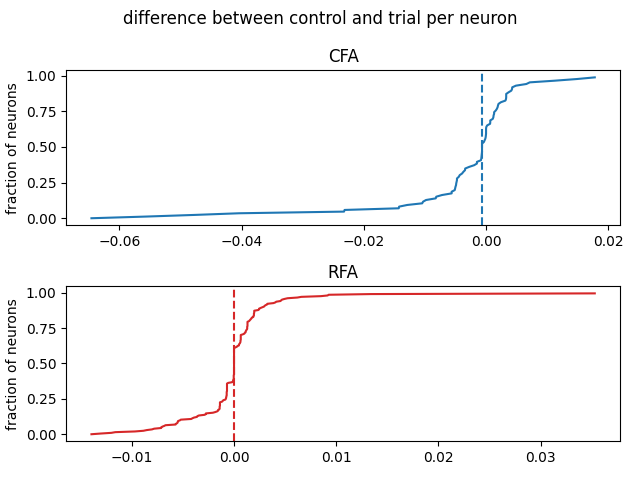

In [8]:
CFA_X = np.sort(CFA_neudiff)
RFA_X = np.sort(RFA_neudiff)

CFA_Y = np.arange(CFA_neudiff.size) / num_CFA
RFA_Y = np.arange(RFA_neudiff.size) / num_RFA

CFA_half_idx = CFA_Y.size // 2
RFA_half_idx = RFA_Y.size // 2
CFA_half = CFA_X[CFA_half_idx]
RFA_half = RFA_X[RFA_half_idx]
 
fig2, ax2 = plt.subplots(2, 1)

fig2.suptitle('difference between control and trial per neuron')

ax2[0].plot(CFA_X, CFA_Y, c='tab:blue')
ax2[0].set_title('CFA')
ax2[0].set_ylabel('fraction of neurons')
ax2[0].axvline(CFA_half, ls='--')
ax2[1].set_ylabel('fraction of neurons')
ax2[1].plot(RFA_X, RFA_Y, c='tab:red')
ax2[1].set_title('RFA')
ax2[1].axvline(RFA_half, color='tab:red', ls='--')

fig2.tight_layout()

# 3. lets start thinking about pairs, first lets get top 1000 pairs, then run CCGs

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0, 0.5, 'count')

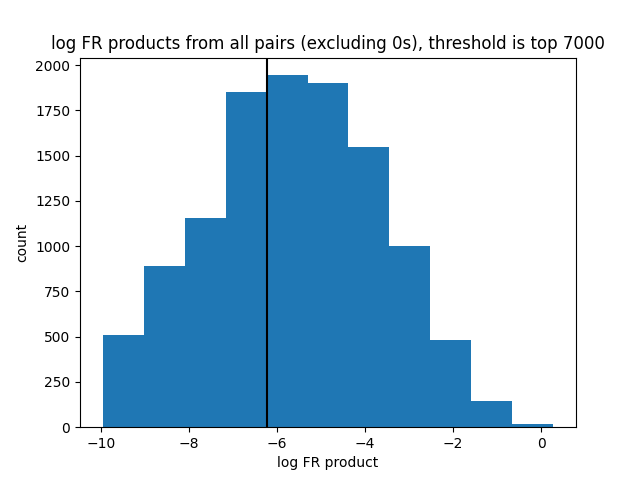

In [43]:
num_top_pairs = 7000

all_pair_products = session.get_top_pair_products() / 0.001
all_pair_products = all_pair_products[all_pair_products > 0]
num_products = all_pair_products.size
fig3, ax3 = plt.subplots()
nada, bins, nada = ax3.hist(nanlog(all_pair_products), bins=num_products//1000)
threshold = bins[-(num_top_pairs//1000 +1)]
ax3.axvline(threshold, color='black')
ax3.set_title(f'log FR products from all pairs (excluding 0s), threshold is top {num_top_pairs}')
ax3.set_xlabel('log FR product')
ax3.set_ylabel('count')

# 4. lets start getting CCGs from top pairs

In [44]:
pair_idxs = session.get_top_pairs(num_top_pairs)
num_unique_CFA = len(np.unique(pair_idxs[:,0]))
num_unique_RFA = len(np.unique(pair_idxs[:,1]))
print(f'num unique CFAs {num_unique_CFA}, num unique RFAs {num_unique_RFA}')

fs=3

CFA_onsetbinned, RFA_onsetbinned = session.binner(bounds=session.laser_bounds[:, [0,3]], fs=fs)
CFA_onsetpairs = CFA_onsetbinned[:, pair_idxs[:, 0], :]
RFA_onsetpairs = RFA_onsetbinned[:, pair_idxs[:, 1], :]

CFA_ctrlbinned, RFA_ctrlbinned = session.binner(bounds=session.ctrl_bounds[:, [0,3]], fs=fs)
CFA_ctrlpairs = CFA_ctrlbinned[:, pair_idxs[:, 0], :]
RFA_ctrlpairs = RFA_ctrlbinned[:, pair_idxs[:, 1], :]

num unique CFAs 80, num unique RFAs 143


## example CCG (for each pair, we calculate a CCG for each trial, and then average all CCGs to get one)

In [45]:
windowsize=5

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


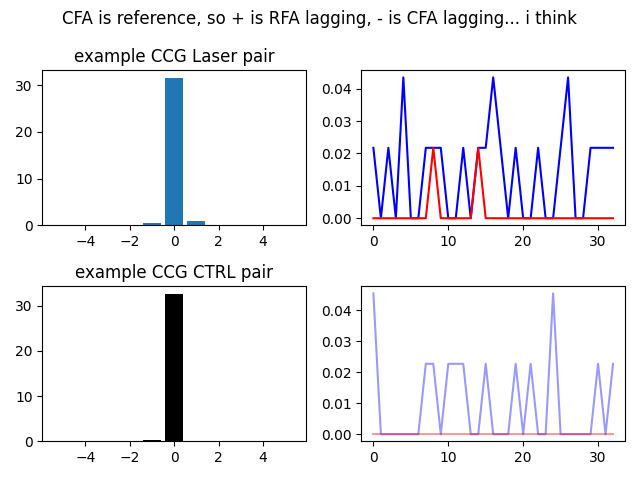

In [46]:
random_pair = random.sample(range(0, num_top_pairs), 1)
example_laserCFA = CFA_onsetpairs[:, random_pair, :]
example_laserRFA = RFA_onsetpairs[:, random_pair, :] 

example_ctrlCFA = CFA_ctrlpairs[:, random_pair, :]
example_ctrlRFA = RFA_ctrlpairs[:, random_pair, :]

example_laserccg = np.squeeze(session.ccg(example_laserCFA, example_laserRFA, windowsize=windowsize))
example_ctrlccg = np.squeeze(session.ccg(example_ctrlCFA, example_ctrlRFA, windowsize=windowsize))

example_laserCFA = np.squeeze(example_laserCFA)
example_laserRFA = np.squeeze(example_laserRFA)
example_ctrlCFA = np.squeeze(example_ctrlCFA)
example_ctrlRFA = np.squeeze(example_ctrlRFA)

fig4, ax4 = plt.subplots(2,2)
X = np.arange(0, example_laserccg.size) - windowsize
ax4[0][0].bar(X, example_laserccg, color='tab:blue')
ax4[0][0].set_title('example CCG Laser pair')
ax4[1][0].bar(X, example_ctrlccg, color='black')
ax4[1][0].set_title('example CCG CTRL pair')
ax4[0][1].plot(np.average(example_laserCFA, axis=1), color='blue')
ax4[0][1].plot(np.average(example_laserRFA, axis=1), color='red')

ax4[1][1].plot(np.average(example_ctrlCFA, axis=1), color='blue', alpha=0.4)
ax4[1][1].plot(np.average(example_ctrlRFA, axis=1), color='red', alpha=0.4)

fig4.suptitle('CFA is reference, so + is RFA lagging, - is CFA lagging... i think')

fig4.tight_layout()

# 5. so how do things differ between laser and control trials

## so I first subtract laser CCGs - ctrl CCGs

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0, 0.5, 'never sure what y axis in a CCG means, correlation coefficient?')

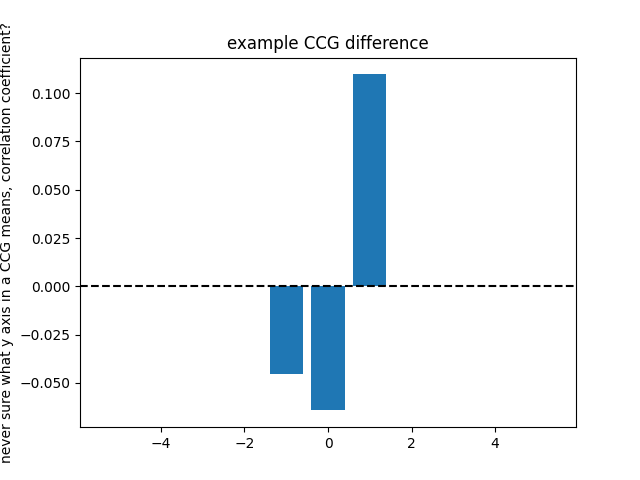

In [47]:
ccgs = session.ccg(CFA_onsetpairs, RFA_onsetpairs, windowsize=windowsize)
ctrl_ccgs = session.ccg(CFA_ctrlpairs, RFA_ctrlpairs, windowsize=windowsize)

ccg_diff = ccgs-ctrl_ccgs
random_pair = random.sample(range(0, num_top_pairs), 1)
ccg_diff_example = np.squeeze(ccg_diff[random_pair, :])

fig5, ax5 = plt.subplots()
X = np.arange(0, ccg_diff_example.size) - windowsize
ax5.axhline(0, color='black', ls='--')
ax5.bar(X, ccg_diff_example, color='tab:blue')
ax5.set_title('example CCG difference')
ax5.set_ylabel('never sure what y axis in a CCG means, correlation coefficient?')

# 6. lets average all of these CCG_diff pairs

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'avg CCG laser - CCG diff')

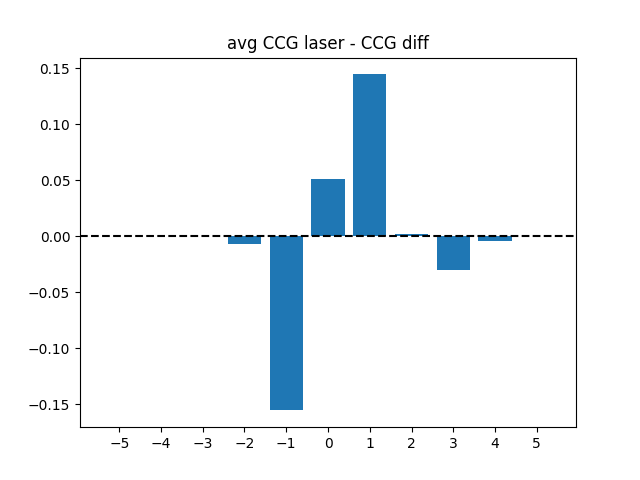

In [48]:
fig6, ax6 = plt.subplots()
X = np.arange(windowsize*2+1) - windowsize
ax6.bar(X, np.average(ccg_diff, axis=0))
ax6.set_xticks(X);
ax6.axhline(0, color='black', ls='--')
ax6.set_title('avg CCG laser - CCG diff')

# 7. what percent of neuron pairs had laser had INCREASED correlation compared to control for different region lagging
## i add up all the negative staggers, and count how many were above 0. then i add up all the positive staggers, then count how many are above 0

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'fraction neurons with increased correlation during laser trials')

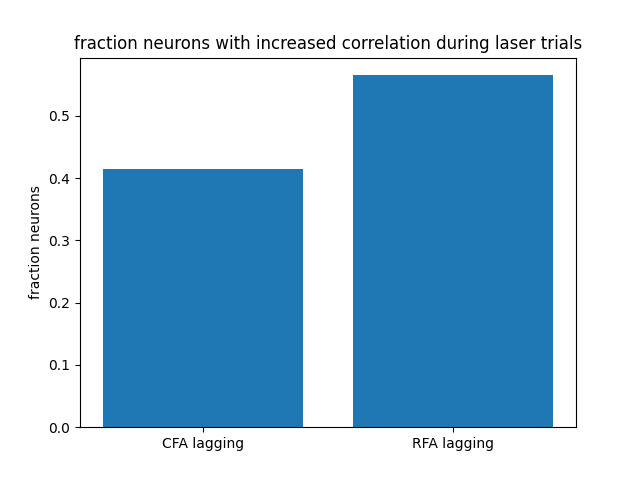

In [49]:
ccg_staggersum = np.zeros((ccg_diff.shape[0], 2))
ccg_staggersum[:, 0] = np.sum(ccg_diff[:, :windowsize], axis=1)
#ccg_staggersum[:, 1] = np.sum(ccg_diff[:, windowsize])
ccg_staggersum[:, 1] = np.sum(ccg_diff[:, windowsize+1:], axis=1)

ccg_staggersum = np.count_nonzero(ccg_staggersum > 0, axis=0) / ccg_diff.shape[0]
fig7, ax7 = plt.subplots()
X = ['CFA lagging', 'RFA lagging']
ax7.bar(X, ccg_staggersum)
ax7.set_ylabel('fraction neurons')
ax7.set_title('fraction neurons with increased correlation during laser trials')

# 8. lets start looking at population stuff, so first lets check out smoothing works

In [27]:
fs=1
sigma=10

CFA_trialsmooth, RFA_trialsmooth = session.smoother(bounds=session.laser_bounds[:, 2:], sigma=sigma)
CFA_ctrlsmooth, RFA_ctrlsmooth =session.smoother(bounds=session.ctrl_bounds[:, 2:], sigma=sigma)

trial_length = CFA_trialsmooth.shape[0]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


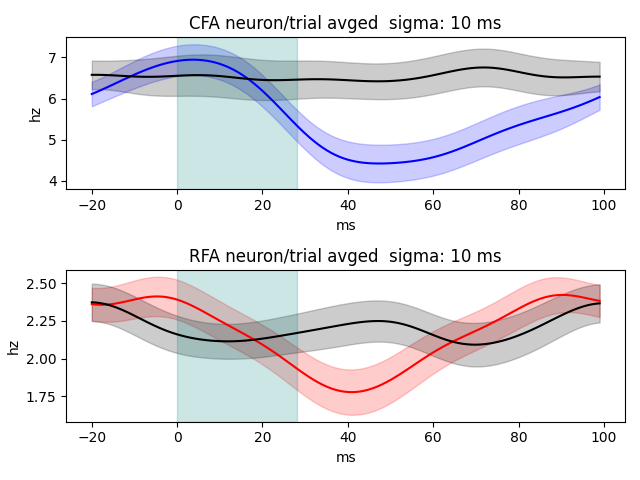

In [28]:
laser_onset = pre//fs
laser_offset = (session.laser_bounds[0,1] - session.laser_bounds[0,0])//fs

CFA_sts_avgavg = np.average(CFA_trialsmooth, axis=(1,2)) / (fs/1000)
temp = np.average(CFA_trialsmooth, axis=1)
CFA_sts_avgsem = np.std(temp, axis=1) / np.sqrt(num_trials) / (fs/1000)

RFA_sts_avgavg = np.average(RFA_trialsmooth, axis=(1,2)) / (fs/1000)
temp = np.average(RFA_trialsmooth, axis=1)
RFA_sts_avgsem = np.std(temp, axis=1) / np.sqrt(num_trials) / (fs/1000)

CFA_ctrlsts_avgavg = np.average(CFA_ctrlsmooth, axis=(1,2)) / (fs/1000)
temp = np.average(CFA_ctrlsmooth, axis=1)
CFA_ctrlsts_avgsem = np.std(temp, axis=1) / np.sqrt(num_ctrls) / (fs/1000)

RFA_ctrlsts_avgavg = np.average(RFA_ctrlsmooth, axis=(1,2)) / (fs/1000)
temp = np.average(RFA_ctrlsmooth, axis=1)
RFA_ctrlsts_avgsem = np.std(temp, axis=1) / np.sqrt(num_ctrls) / (fs/1000)

x = np.arange(0, trial_length*fs, fs) - laser_onset*fs

fig8, ax8 = plt.subplots(2, 1)
ax8[0].plot(x, CFA_sts_avgavg, color='blue')
ax8[0].plot(x, CFA_ctrlsts_avgavg, color='black')
ax8[0].fill_between(x, CFA_sts_avgavg - CFA_sts_avgsem, CFA_sts_avgavg + CFA_sts_avgsem, color='blue', alpha=0.2)
ax8[0].fill_between(x, CFA_ctrlsts_avgavg - CFA_ctrlsts_avgsem, CFA_ctrlsts_avgavg + CFA_ctrlsts_avgsem, color='black', alpha=0.2)
ax8[0].axvspan(0, (laser_offset - laser_onset)*fs, color='teal', alpha=0.2)
ax8[0].set_ylabel('hz')
ax8[0].set_title(f'CFA neuron/trial avged  sigma: {sigma} ms')
ax8[0].set_xlabel('ms')

ax8[1].plot(x, RFA_sts_avgavg, color='red')
ax8[1].plot(x, RFA_ctrlsts_avgavg, color='black')
ax8[1].fill_between(x, RFA_sts_avgavg - RFA_sts_avgsem, RFA_sts_avgavg + RFA_sts_avgsem, color='red', alpha=0.2)
ax8[1].fill_between(x, RFA_ctrlsts_avgavg - RFA_ctrlsts_avgsem, RFA_ctrlsts_avgavg + RFA_ctrlsts_avgsem, color='black', alpha=0.2)
ax8[1].axvspan(0, (laser_offset - laser_onset)*fs, color='teal', alpha=0.2)
ax8[1].set_title(f'RFA neuron/trial avged  sigma: {sigma} ms')
ax8[1].set_xlabel('ms')
ax8[1].set_ylabel('hz')


fig8.tight_layout()

# 9. okay, now lets smooth ALL climbing data (concatenated), and then run PCA on it

In [18]:
CFA_PCAobj, RFA_PCAobj = session.apply_PCA(bounds=session.climbing_bounds)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


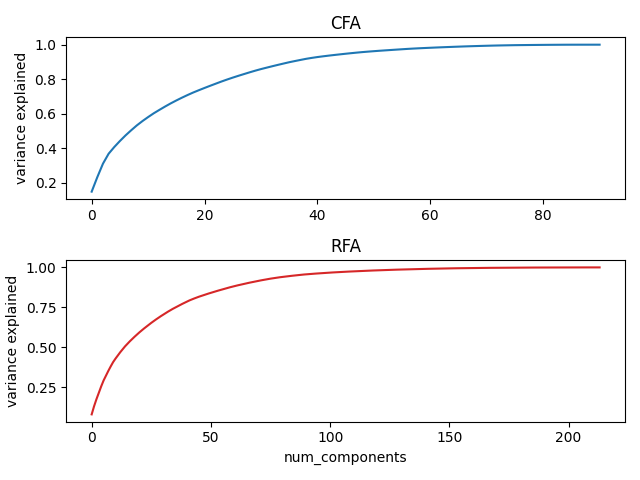

In [19]:
fig9, ax9 = plt.subplots(2, 1)
ax9[0].plot(np.cumsum(CFA_PCAobj.explained_variance_ratio_), color='tab:blue')
ax9[0].set_ylabel('variance explained')
ax9[0].set_title('CFA')
ax9[1].set_ylabel('variance explained')
ax9[1].set_xlabel('num_components')
ax9[1].set_title('RFA')
ax9[1].set_ylabel('variance explained')
ax9[1].plot(np.cumsum(RFA_PCAobj.explained_variance_ratio_), color='tab:red')

fig9.tight_layout()

# 10. what happens when we project CTRL trials onto these PCs

## first lets smooth and concatenate all CTRL trials

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


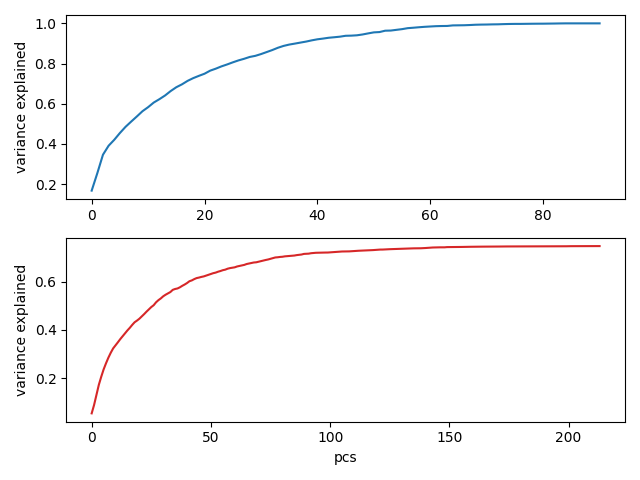

In [20]:
CFA_ctrlsmooth, RFA_ctrlsmooth = session.smoother(bounds=session.ctrl_bounds[:,[0,3]], concat=True)
CFA_ctrlPCs = CFA_PCAobj.transform(CFA_ctrlsmooth) 
RFA_ctrlPCs = RFA_PCAobj.transform(RFA_ctrlsmooth) 

total_CFA_var = np.sum(np.var(CFA_ctrlPCs, axis=0))
total_RFA_var = np.sum(np.var(RFA_ctrlPCs, axis=0))

CFA_ctrl_varatio = np.var(CFA_ctrlPCs, axis=0) / total_CFA_var
RFA_ctrl_varatio = np.var(RFA_ctrlPCs, axis=0) / total_CFA_var

fig10, ax10 = plt.subplots(2, 1)
ax10[0].plot(np.cumsum(CFA_ctrl_varatio), color='tab:blue')
ax10[0].set_ylabel('variance explained')
ax10[1].set_ylabel('variance explained')
ax10[1].set_xlabel('pcs')
ax10[1].plot(np.cumsum(RFA_ctrl_varatio), color='tab:red')

fig10.tight_layout()




## 10.1 what about an individual ctrl trial

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


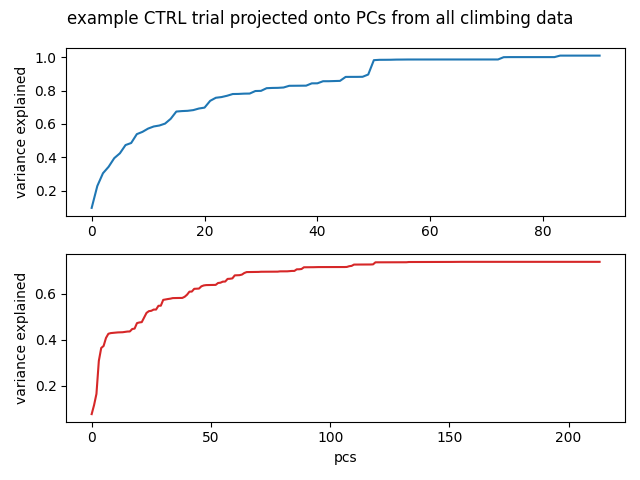

In [21]:
CFA_ctrlsmooth, RFA_ctrlsmooth = session.smoother(bounds=session.ctrl_bounds[:,[0,3]], concat=False)
random_trial = random.sample(range(0, CFA_ctrlsmooth.shape[2]), 1)

CFA_1ctrlPCs = CFA_PCAobj.transform(np.squeeze(CFA_ctrlsmooth[:,:,random_trial])) 
RFA_1ctrlPCs = RFA_PCAobj.transform(np.squeeze(RFA_ctrlsmooth[:,:,random_trial])) 

total_1CFA_var = np.sum(np.var(CFA_1ctrlPCs, axis=0))
total_1RFA_var = np.sum(np.var(RFA_1ctrlPCs, axis=0))

CFA_1ctrl_varatio = np.var(CFA_1ctrlPCs, axis=0) / total_CFA_var
RFA_1ctrl_varatio = np.var(RFA_1ctrlPCs, axis=0) / total_CFA_var

fig10_1, ax10_1 = plt.subplots(2, 1)
ax10_1[0].plot(np.cumsum(CFA_1ctrl_varatio), color='tab:blue')
ax10_1[0].set_ylabel('variance explained')
ax10_1[1].set_ylabel('variance explained')
ax10_1[1].set_xlabel('pcs')
ax10_1[1].plot(np.cumsum(RFA_1ctrl_varatio), color='tab:red')

fig10_1.suptitle('example CTRL trial projected onto PCs from all climbing data')
fig10_1.tight_layout()

# 11 what happens when we project concatenated LASER trials

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


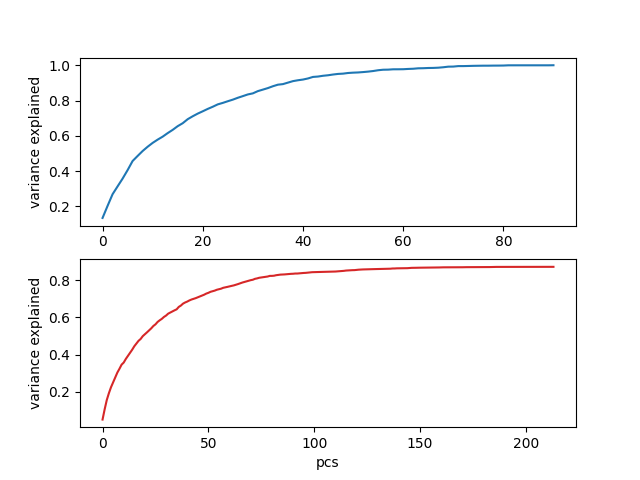

In [22]:
CFA_trialsmooth, RFA_trialsmooth = session.smoother(bounds=session.laser_bounds[:,[0,3]], concat=True)
CFA_trialPCs = CFA_PCAobj.transform(CFA_trialsmooth) 
RFA_trialPCs = RFA_PCAobj.transform(RFA_trialsmooth) 

total_CFA_trialvar = np.sum(np.var(CFA_trialPCs, axis=0))
total_RFA_trialvar = np.sum(np.var(RFA_trialPCs, axis=0))

CFA_trial_varatio = np.var(CFA_trialPCs, axis=0) / total_CFA_trialvar
RFA_trial_varatio = np.var(RFA_trialPCs, axis=0) / total_CFA_trialvar

fig11, ax11 = plt.subplots(2, 1)
ax11[0].plot(np.cumsum(CFA_trial_varatio), color='tab:blue')
ax11[0].set_ylabel('variance explained')
ax11[1].set_ylabel('variance explained')
ax11[1].set_xlabel('pcs')
ax11[1].plot(np.cumsum(RFA_trial_varatio), color='tab:red')

## 11.1 and individual laser trials

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


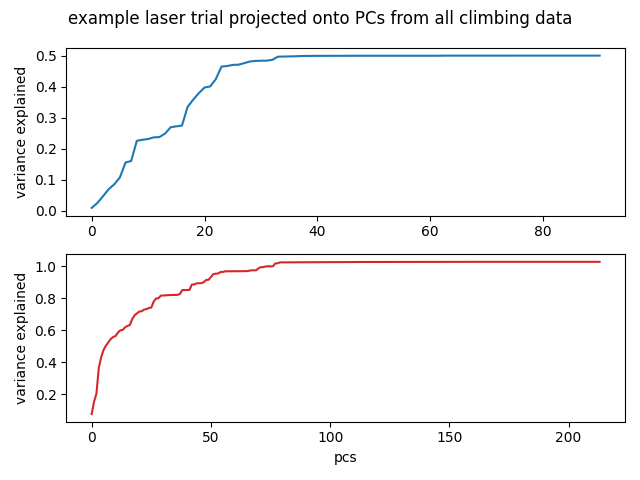

In [50]:
CFA_trialsmooth, RFA_trialsmooth = session.smoother(bounds=session.laser_bounds[:,[0,3]], concat=False)
random_trial = random.sample(range(0, CFA_trialsmooth.shape[2]), 1)

CFA_1trialPCs = CFA_PCAobj.transform(np.squeeze(CFA_trialsmooth[:,:,random_trial])) 
RFA_1trialPCs = RFA_PCAobj.transform(np.squeeze(RFA_trialsmooth[:,:,random_trial])) 

total_1trialCFA_var = np.sum(np.var(CFA_1trialPCs, axis=0))
total_1trialRFA_var = np.sum(np.var(RFA_1trialPCs, axis=0))

CFA_1trial_varatio = np.var(CFA_1trialPCs, axis=0) / total_CFA_var
RFA_1trial_varatio = np.var(RFA_1trialPCs, axis=0) / total_RFA_var

fig11_1, ax11_1 = plt.subplots(2, 1)
ax11_1[0].plot(np.cumsum(CFA_1trial_varatio), color='tab:blue')
ax11_1[0].set_ylabel('variance explained')
ax11_1[1].set_ylabel('variance explained')
ax11_1[1].set_xlabel('pcs')
ax11_1[1].plot(np.cumsum(RFA_1trial_varatio), color='tab:red')

fig11_1.suptitle('example laser trial projected onto PCs from all climbing data')
fig11_1.tight_layout()

# general thoughts: 
activity during pertubation trials not so different than during actual trials in population structure

## ez todos: 
CCGs with some sort of peak thresholding, one-way smoothing
## other todos
start thinking about basic modeling of firing rate, if we model everything can we still predict perbuation firing rates
start looking at different laser powers